In [45]:
#--------------------------------------
# ALL IMPORTS
#--------------------------------------

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
#--------------------------------------
# STUDY WINE DATA SET
#--------------------------------------

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
# -----COMMENT CODE ------------ X['target'] = wine.target
y = pd.Series(wine.target, name="target")

# -----COMMENT CODE ------------ print(wine.DESCR)


#--------------------------------------
# SPLIT TRAIN/TEST DATA 80/20, random state=67
#--------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=67,
    stratify=y
)

## Scale/Transform after splitting
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled training data back to a DataFrame
train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

# Add target labels to the scaled training DataFrame
train_scaled_df["target"] = y_train.values

train_scaled_df.head()


#--------------------------------------
# CONCLUSION
#--------------------------------------

#
# 13 features: 
#   1. alcohol
#   2. malic acid
#   3. ash
#   4. alcalinity
#   5. magnesium
#   6. phenols
#   7. flavonoids
#   8. nonflavanoid
#   9. proanthocyanins
#   10. color intensity
#   11. hue
#   12. OD280/OD315
#   13. prolene
  
# 3 classes: class 0, class 1, class 2


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
168,0.742759,0.217277,1.177469,1.491270,0.367489,-1.212185,-1.204980,0.204932,-0.100757,1.658608,-0.966437,-1.139469,0.049733,2
137,-0.580364,2.794981,0.993449,1.638162,-0.280305,-0.822346,-1.442244,2.097634,-0.844881,-0.005829,-0.620716,-1.297257,-0.725775,2
29,1.297211,-0.574510,-0.589123,-1.005904,-0.280305,0.574578,0.268036,-0.820282,0.643367,-0.142258,0.330018,1.428174,0.990243,0
106,-0.933197,-0.530522,-0.920360,-0.124548,-1.431939,-1.049752,-0.028544,0.047206,0.051450,-0.733451,0.157157,0.825711,-0.742276,1
49,1.196401,-0.530522,-0.368299,-0.594604,0.583420,0.948174,1.464244,-0.347106,0.812486,1.767751,0.675739,0.725300,1.732751,0


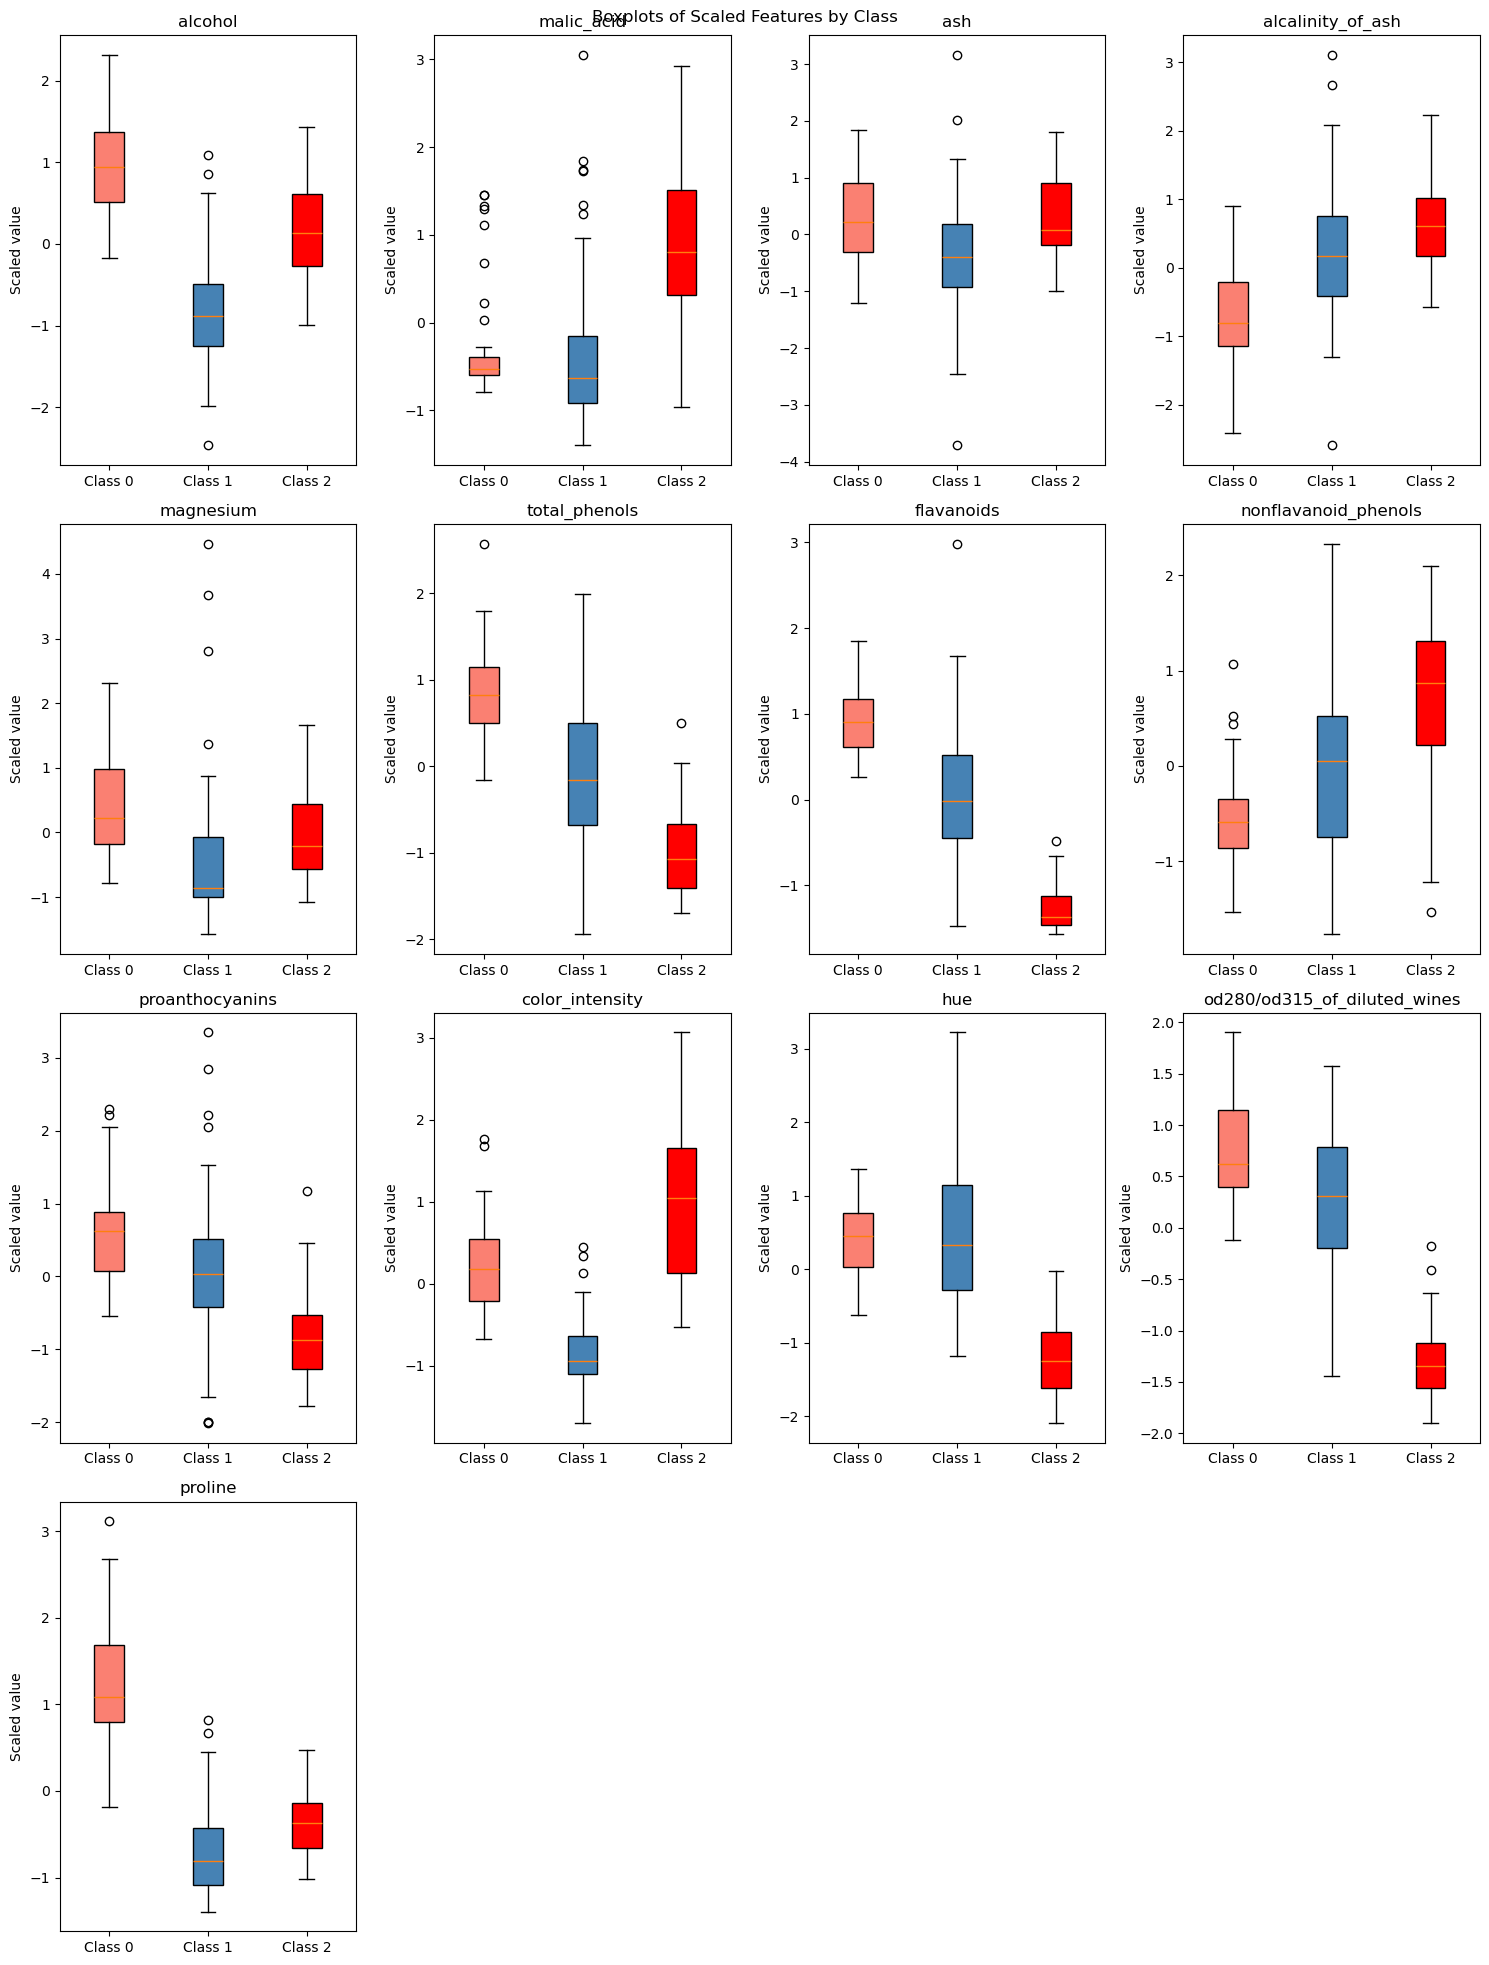

In [47]:
#--------------------------------------
# FEATURE SELECTION
#--------------------------------------

# ==================================================================
# STRATEGY 1 — Scaled Boxplots by Class
# ==================================================================
# Goal: Look at each feature and ask:
#   "Do the two classes sit in different
#    places, or do they overlap a lot?"
#
# A feature where the boxes barely touch is USEFUL.
# A feature where the boxes overlap is NOT very useful.
# ==================================================================

# --- Pick a subset of features to keep the plot readable -----------
# Strategy 1: Boxplots of scaled features by class

features_to_plot = [
    "alcohol",
    "malic_acid",
    'ash',
    'alcalinity_of_ash',
    'magnesium',
    'total_phenols',
    'flavanoids',
    'nonflavanoid_phenols',
    'proanthocyanins',
    'color_intensity',
    'hue',
    'od280/od315_of_diluted_wines',
    'proline'	
]

fig, axes = plt.subplots(4, 4, figsize=(15, 20))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    zero_values = train_scaled_df[train_scaled_df["target"] == 0][feat]
    one_values = train_scaled_df[train_scaled_df["target"] == 1][feat]
    two_values = train_scaled_df[train_scaled_df["target"] == 2][feat]

    box = axes[i].boxplot(
        [zero_values, one_values, two_values],
        tick_labels=["Class 0", "Class 1", "Class 2"],
        patch_artist=True
    )

    colors = ["salmon", "steelblue", "red"]
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    axes[i].set_title(feat)
    axes[i].set_ylabel("Scaled value")

# Hide any unused subplots
for j in range(len(features_to_plot), len(axes)):
    axes[j].axis('off')

plt.suptitle("Boxplots of Scaled Features by Class")
plt.tight_layout()
plt.show()



In [48]:
#--------------------------------------
# FEATURE SELECTION
#--------------------------------------

#--------------------------------------
# CONCLUSION
#--------------------------------------

# Features to differentate
# 1. flavanoids (differentiate class 2)
# 2. color_intensity (differentiate class 1)
# 3. od280/od315_of_diluted_wines (differentiate class 2)
# 4. proline (differentiate class 0)

selected_features = [
    "flavanoids",
    "color_intensity",
    "od280/od315_of_diluted_wines",
    "proline"
]

# Extract only the chosen features from the scaled training DataFrame
X_train_selected = train_scaled_df[selected_features]

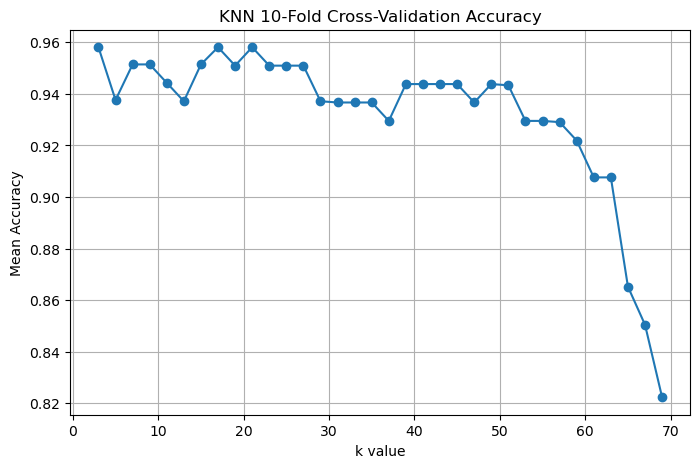

In [49]:

# -----------------------------
# Cross-validation to pick k
# -----------------------------

# Define a list of odd k values to try
max_k = len(X_train_scaled) // 2
k_list = list(range(3, max_k, 2))

# Prepare to store cross-validation results
cross_validation_scores = []
all_scores = {}

# Create a KFold object
kf = KFold(n_splits=10, shuffle=True, random_state=35) #

# Run cross-validation for each k
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', p=3) ## use euclidean
    scores = cross_val_score(knn, X_train_selected, y_train, cv=kf, scoring='accuracy')
    cross_validation_scores.append(scores.mean())
    all_scores[k] = scores

# -----------------------------
# Plot CV accuracy vs. k
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.plot(k_list, cross_validation_scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Mean Accuracy')
plt.title('KNN 10-Fold Cross-Validation Accuracy')
plt.grid(True)
plt.show()


In [50]:
# -----------------------------
# Select the best k and retrain the model
# -----------------------------
best_k_index = np.argmax(cross_validation_scores)
best_k = k_list[best_k_index]
print(f"Best k from CV: {best_k}")

# Retrain the model using the best k
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', p=3)
final_knn.fit(X_train_selected, y_train)

# -----------------------------
# Evaluate on test set
# -----------------------------
X_test_selected = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)[selected_features]

y_pred = final_knn.predict(X_test_selected)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test-set Accuracy: {test_acc:.3f}")

Best k from CV: 3
Test-set Accuracy: 1.000


In [51]:
## Final Accuracy Score: 100%, from k=3 KNN

In [52]:
'''
------------- Which four features did you select for your KNN model? Why did you select these features?

1. flavanoids (differentiate class 2)
2. color_intensity (differentiate class 1)
3. od280/od315_of_diluted_wines (differentiate class 2)
4. proline (differentiate class 0)

By looking at the scaled boxplots, I picked the features where the classes barely overlap, so it is easier for the KNN to differentiate classes


------------ How did you split your data into training and testing sets?

Split the data into 80% training and 20% testing with random state = 67


-------------Describe your process for selecting the optimal value of ( k ).

Make use of a 10-fold Cross Validation technique to find the most accurate k for KNN within a range of 3 to half the training data size


-------------What range of ( k ) values did you test?
k values within the range 3 - 71


------------What was the optimal value of ( k ), and how did you decide on it?
Optimal value of k=3, the k value with the highest accuracy score in a 10-fold cross validation technique

------------How well did your final KNN model perform on the test set? What was the final accuracy score?
It performed well with a accuracy score of 100%

------------Did you collaborate with anyone or receive help from any AI tool on this assignment? If so, please identify the person or tool and briefly describe the help received. (If you used AI, what was helpful and what was not helpful?)
No AI tool was used, code was all referenced through the lecture notes and tutorial code

------------What did you learn from this project?
1. it is important to study the dataset and identify useful features instead of training the model with 'useless' features
2. it is important to validate the accuracy (k-fold cross validation etc) in order to maximise the accuracy
3. there are multiple validation techniques and models to use

------------What challenges did you encounter, and how did you overcome them?
many different topics/strategies to remember and alot of code that had to require searching and looking up notes

'''

"\n------------- Which four features did you select for your KNN model? Why did you select these features?\n\n1. flavanoids (differentiate class 2)\n2. color_intensity (differentiate class 1)\n3. od280/od315_of_diluted_wines (differentiate class 2)\n4. proline (differentiate class 0)\n\nBy looking at the scaled boxplots, I picked the features where the classes barely overlap, so it is easier for the KNN to differentiate classes\n\n\n------------ How did you split your data into training and testing sets?\n\nSplit the data into 80% training and 20% testing with random state = 67\n\n\n-------------Describe your process for selecting the optimal value of ( k ).\n\nMake use of a 10-fold Cross Validation technique to find the most accurate k for KNN within a range of 3 to half the training data size\n\n\n-------------What range of ( k ) values did you test?\nk values within the range 3 - 71\n\n\n------------What was the optimal value of ( k ), and how did you decide on it?\nOptimal value of